# 03 Inference

## 1. Data

In [20]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

ROOT = Path.cwd().resolve().parent

PROCESSED_PATH = ROOT / "data" / "processed" / "yrbs_cycle3_q8_processed_only.csv"

FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

analysis = pd.read_csv(PROCESSED_PATH)

required_cols = ["sad_binary", "sad_group", "smoker_binary"]
missing_cols = [col for col in required_cols if col not in analysis.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. Please rerun 01_DataCheck.ipynb first.")

analysis["sad_binary"] = analysis["sad_binary"].astype(int)
analysis["smoker_binary"] = analysis["smoker_binary"].astype(int)

print("Rows valid for both SadOrHopeless and CurrentCigaretteUse:", len(analysis))

Rows valid for both SadOrHopeless and CurrentCigaretteUse: 13174


## 2. Method Choice

The response variable is `smoker_binary`, which is binary:

- `1` = current cigarette use, meaning the student reported smoking cigarettes on at least 1 day in the past 30 days.
- `0` = no current cigarette use, meaning the student reported 0 smoking days in the past 30 days.

Because this project compares two proportions, the appropriate statistical method is a **two-proportion z-test**.

The estimated difference is defined as:

`p_yes - p_no`

where:

- `p_yes` = current cigarette use proportion among students who felt sad or hopeless.
- `p_no` = current cigarette use proportion among students who did not feel sad or hopeless.

## 3. Hypotheses

Let:

- `p_yes` = the current cigarette use proportion for students who felt sad or hopeless.
- `p_no` = the current cigarette use proportion for students who did not feel sad or hopeless.

Hypotheses:

- **H0:** `p_yes = p_no`
- **H1:** `p_yes != p_no`

This is a two-sided test because the research question asks whether the proportions are **different** between the two groups.

## 4. 95% Confidence Interval for Difference in Proportions

### 4.1 CI Summary Table

In [21]:
summary = analysis.groupby(["sad_binary", "sad_group"]).agg(
    n=("smoker_binary", "count"),
    current_cigarette_users=("smoker_binary", "sum"),
    current_cigarette_proportion=("smoker_binary", "mean")
).reset_index()

n_yes = int(summary.loc[summary["sad_binary"] == 1, "n"].iloc[0])
x_yes = int(summary.loc[summary["sad_binary"] == 1, "current_cigarette_users"].iloc[0])
p_yes = float(summary.loc[summary["sad_binary"] == 1, "current_cigarette_proportion"].iloc[0])

n_no = int(summary.loc[summary["sad_binary"] == 0, "n"].iloc[0])
x_no = int(summary.loc[summary["sad_binary"] == 0, "current_cigarette_users"].iloc[0])
p_no = float(summary.loc[summary["sad_binary"] == 0, "current_cigarette_proportion"].iloc[0])

diff = p_yes - p_no

se_ci = math.sqrt(
    p_yes * (1 - p_yes) / n_yes
    + p_no * (1 - p_no) / n_no
)

zcrit = norm.ppf(0.975)
ci_low = diff - zcrit * se_ci
ci_high = diff + zcrit * se_ci

ci_summary_table = pd.DataFrame({
    "metric": [
        "Sad/Hopeless: Yes proportion",
        "Sad/Hopeless: No proportion",
        "Difference in proportions",
        "Standard error for CI",
        "95% CI lower bound",
        "95% CI upper bound",
        "95% CI"
    ],
    "value": [
        round(p_yes, 4),
        round(p_no, 4),
        round(diff, 4),
        round(se_ci, 4),
        round(ci_low, 4),
        round(ci_high, 4),
        f"[{ci_low:.4f}, {ci_high:.4f}]"
    ],
})

ci_summary_table.to_csv(TAB_DIR / "03_difference_ci_summary.csv", index=False)
display(ci_summary_table)

,metric,value
0,Sad/Hopeless: Yes proportion,0.2761
1,Sad/Hopeless: No proportion,0.1618
2,Difference in proportions,0.1143
3,Standard error for CI,0.0081
4,95% CI lower bound,0.0983
5,95% CI upper bound,0.1302
6,95% CI,"[0.0983, 0.1302]"


#### **Interpretation**

The estimated current cigarette use proportion was higher in the **Sad/Hopeless: Yes** group than in the **Sad/Hopeless: No** group. Specifically, the proportion was **0.2761** for students who felt sad or hopeless, compared with **0.1618** for students who did not feel sad or hopeless.

The estimated difference was **0.1143**, calculated as **0.2761 - 0.1618**. This means that the current cigarette use proportion in the **Sad/Hopeless: Yes** group was higher than in the **Sad/Hopeless: No** group.

The 95% confidence interval for the difference was **[0.0983, 0.1302]**. Since the entire interval is above 0, the result suggests that students who felt sad or hopeless had a higher current cigarette use proportion than students who did not.

However, this result should be interpreted as an **association**, not a causal relationship, because the YRBS data are observational survey data.

### 4.2 CI Plot

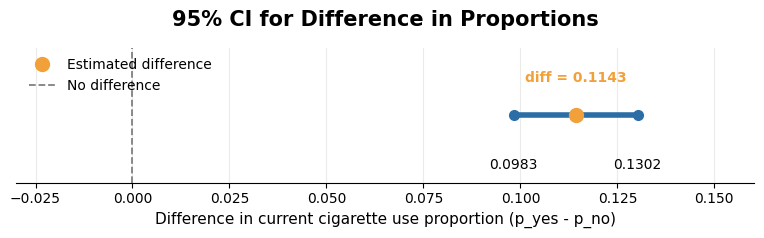

In [22]:
# ------------------------------------------------------------
# Visualization: 95% confidence interval for difference
# Difference is defined as p_yes - p_no
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.2, 2.8))

# CI line
ax.hlines(
    y=0,
    xmin=ci_low,
    xmax=ci_high,
    linewidth=4,
    color="#2b6ea6"
)

# End points
ax.plot([ci_low, ci_high], [0, 0], "o", color="#2b6ea6", markersize=7)

# Estimated difference
ax.plot(
    diff,
    0,
    "o",
    color="#f2a13a",
    markersize=10,
    label="Estimated difference"
)

# Reference line at 0
ax.axvline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1.3,
    label="No difference"
)

# -----------------------------
# Text labels
# -----------------------------

# CI endpoints: place BELOW the line
ax.text(
    ci_low,
    -0.22,
    f"{ci_low:.4f}",
    ha="center",
    va="top",
    fontsize=10
)

ax.text(
    ci_high,
    -0.22,
    f"{ci_high:.4f}",
    ha="center",
    va="top",
    fontsize=10
)

# Difference label: place ABOVE the point
ax.text(
    diff,
    0.16,
    f"diff = {diff:.4f}",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
    color="#f2a13a"
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_yticks([])
ax.set_ylim(-0.35, 0.35)

ax.set_xlabel(
    "Difference in current cigarette use proportion (p_yes - p_no)",
    fontsize=11
)

ax.set_title(
    "95% CI for Difference in Proportions",
    fontsize=15,
    fontweight="bold",
    pad=16
)

x_margin = 0.03
ax.set_xlim(min(0, ci_low) - x_margin, ci_high + x_margin)

ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, 1.02),
    frameon=False,
    fontsize=10
)

ax.grid(axis="x", alpha=0.25)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.30,
    top=0.78
)

fig.savefig(
    FIG_DIR / "03_difference_in_proportions_ci_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Interpretation

The estimated difference was 0.1143, and the 95% confidence interval was [0.0983, 0.1302]. Since the entire interval is above 0, the result suggests that the current cigarette use proportion was higher in the Sad/Hopeless: Yes group.

## 5. Two-Proportion z-test

In [23]:
p_pool = (x_yes + x_no) / (n_yes + n_no)

se_test = math.sqrt(
    p_pool * (1 - p_pool) * (1 / n_yes + 1 / n_no)
)

z_stat = diff / se_test
p_value = 2 * (1 - norm.cdf(abs(z_stat)))
p_value_display = "< 0.0001" if p_value < 0.0001 else f"{p_value:.4f}"

decision = "Reject H0" if p_value < 0.05 else "Fail to reject H0"

test_summary_table = pd.DataFrame({
    "metric": [
        "Null hypothesis",
        "Alternative hypothesis",
        "Pooled proportion",
        "Standard error for test",
        "z statistic",
        "p-value",
        "Alpha level",
        "Decision"
    ],
    "value": [
        "p_yes = p_no",
        "p_yes ≠ p_no",
        round(p_pool, 4),
        round(se_test, 4),
        round(z_stat, 4),
        p_value_display,
        0.05,
        decision
    ],
})

test_summary_table.to_csv(TAB_DIR / "03_two_proportion_z_test_summary.csv", index=False)
display(test_summary_table)

,metric,value
0,Null hypothesis,p_yes = p_no
1,Alternative hypothesis,p_yes ≠ p_no
2,Pooled proportion,0.1952
3,Standard error for test,0.0076
4,z statistic,15.0536
5,p-value,< 0.0001
6,Alpha level,0.05
7,Decision,Reject H0


#### **Interpretation**

A **two-proportion z-test** was used to compare the current cigarette use proportions between the **Sad/Hopeless: Yes** and **Sad/Hopeless: No** groups.

The **pooled proportion** was **0.1952**, meaning that if the two groups are combined, about **19.52%** of students in the valid sample were current cigarette users. This pooled proportion is used in the hypothesis test because the null hypothesis assumes the two groups have the same population proportion.

The test result was **z = 15.0536** with **p-value < 0.0001**. Since the p-value is smaller than **α = 0.05**, we **reject H0**.

This provides statistically significant evidence that the current cigarette use proportion is different between the two groups. Based on the sample proportions, the **Sad/Hopeless: Yes** group had a higher current cigarette use proportion.

This result shows an **association**, not causation, because the YRBS data are observational survey data.

## 6. Save Inference Summary Table

In [24]:
inference = pd.DataFrame({
    "method": ["Two-proportion z-test"],
    "comparison": ["p_yes - p_no"],

    "n_yes": [n_yes],
    "x_yes": [x_yes],
    "p_yes": [round(p_yes, 4)],

    "n_no": [n_no],
    "x_no": [x_no],
    "p_no": [round(p_no, 4)],

    "difference": [round(diff, 4)],
    "ci_95": [f"[{ci_low:.4f}, {ci_high:.4f}]"],

    "z_statistic": [round(z_stat, 4)],
    "p_value": [p_value_display],
    "alpha": [0.05],
    "decision": [decision]
})

inference.to_csv(TAB_DIR / "03_inference_summary.csv", index=False)